In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from IPython.display import display

from sklearn import metrics

# versions
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"tensorflow: {tf.__version__}")

numpy: 2.4.6
pandas: 3.0.3
seaborn: 0.13.2
tensorflow: 2.21.0


In [11]:
data_path = Path("../Finalized_Feature_Sets/model_data_simple.parquet")

model_data_simple = pd.read_parquet(
    data_path,
    engine="pyarrow"
)

model_data_simple.shape

(1700, 31)

# Baseline residual MLP / ResNet-style model for tabular data using TensorFlow/Keras

* isolated imports for clarity

In [12]:
# Define train/test features and outcome
feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

random_seed = 321

np.random.seed(random_seed)
tf.random.set_seed(random_seed)

In [14]:
# One-hot encode categorical predictors

x_train = pd.get_dummies(x_train, drop_first=False)
x_test = pd.get_dummies(x_test, drop_first=False)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

print(set(x_train.columns) - set(x_test.columns))  # should be empty set
print(x_train.shape)
print(x_test.shape)

set()
(1274, 46)
(426, 46)


In [15]:
# Standardize predictors

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

## Defining the Model Architecture

In [16]:
# Define a basic residual block

def residual_block(x, units, dropout_rate=0.10):
    shortcut = x

    x = tf.keras.layers.Dense(units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Dense(units, activation=None)(x)

    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.Activation("relu")(x)

    return x

In [17]:
# Build basic ResNet-style tabular model

input_dim = x_train_scaled.shape[1]

inputs = tf.keras.Input(shape=(input_dim,))

# Project input to 32 dimensions so residual blocks have matching dimensions
x = tf.keras.layers.Dense(32, activation="relu")(inputs)

# Basic residual blocks
x = residual_block(x, units=32, dropout_rate=0.10)
x = residual_block(x, units=32, dropout_rate=0.10)

# Final classification layer
x = tf.keras.layers.Dense(16, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

resnet_model = tf.keras.Model(inputs=inputs, outputs=outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

resnet_model.summary()

InternalError: cudaSetDevice() on GPU:0 failed. Status: out of memory

## Fit the Model

In [9]:
history = resnet_model.fit(
    x_train_scaled,
    y_train_array,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


I0000 00:00:1781133809.446741   26482 service.cc:153] XLA service 0x7fa51003a490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781133809.446757   26482 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1781133809.471529   26482 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781133809.646793   26482 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1781133809.687697   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3356__.29


 1/32 ━━━━━━━━━━━━━━━━━━━━ 1:30 3s/step - accuracy: 0.4062 - loss: 0.8324 - pr_auc: 0.3365 - roc_auc: 0.4688

I0000 00:00:1781133811.433846   26482 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1781133811.674199   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3356__.29


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.6987 - loss: 0.6157 - pr_auc: 0.2698 - roc_auc: 0.5232 - val_accuracy: 0.8667 - val_loss: 0.4648 - val_pr_auc: 0.1535 - val_roc_auc: 0.4817
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7625 - loss: 0.5223 - pr_auc: 0.4365 - roc_auc: 0.6748 - val_accuracy: 0.8549 - val_loss: 0.4741 - val_pr_auc: 0.1749 - val_roc_auc: 0.4914
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.4849 - pr_auc: 0.5336 - roc_auc: 0.7478 - val_accuracy: 0.8078 - val_loss: 0.4989 - val_pr_auc: 0.1730 - val_roc_auc: 0.5016
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7978 - loss: 0.4655 - pr_auc: 0.5845 - roc_auc: 0.7671 - val_accuracy: 0.7843 - val_loss: 0.5052 - val_pr_auc: 0.1793 - val_roc_auc: 0.5160
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8037 - loss: 0.4481 - pr_auc: 0.6330 - roc_auc: 0.7880 - val_accuracy: 0.7765 - val_loss: 0.5250 - val_pr_auc: 0.1733 - val_r

In [10]:
# Predict on test set

y_prob = resnet_model.predict(x_test_scaled).ravel()
y_pred = (y_prob >= 0.50).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


## Metrics and Evaluation

In [11]:
# Evaluate performance

print("Accuracy:", accuracy_score(y_test_array, y_pred))
print("Precision:", precision_score(y_test_array, y_pred, zero_division=0))
print("Recall:", recall_score(y_test_array, y_pred, zero_division=0))
print("F1:", f1_score(y_test_array, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test_array, y_prob))
print("PR AUC:", average_precision_score(y_test_array, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_array, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_array, y_pred, zero_division=0))

Accuracy: 0.7136150234741784
Precision: 0.4222222222222222
Recall: 0.35185185185185186
F1: 0.3838383838383838
ROC AUC: 0.6581498951781971
PR AUC: 0.42195552118765806

Confusion Matrix:
[[266  52]
 [ 70  38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       318
           1       0.42      0.35      0.38       108

    accuracy                           0.71       426
   macro avg       0.61      0.59      0.60       426
weighted avg       0.70      0.71      0.70       426



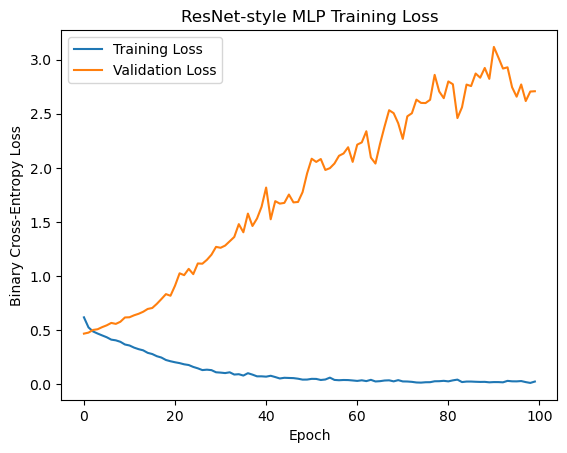

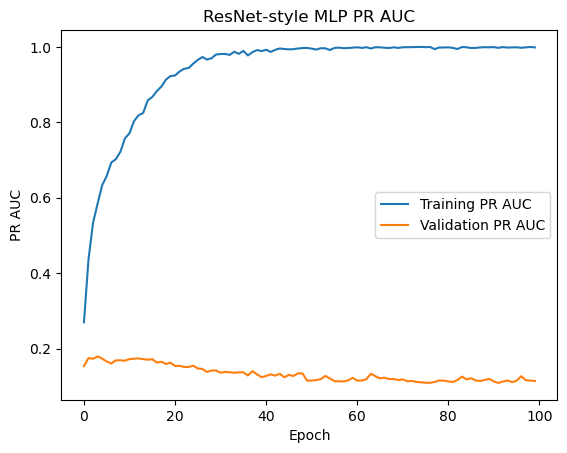

In [12]:
# Plot training curves

import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("ResNet-style MLP Training Loss")
plt.legend()
plt.show()

plt.plot(history.history["pr_auc"], label="Training PR AUC")
plt.plot(history.history["val_pr_auc"], label="Validation PR AUC")
plt.xlabel("Epoch")
plt.ylabel("PR AUC")
plt.title("ResNet-style MLP PR AUC")
plt.legend()
plt.show()

## Hyperparameters and Training Setup

__5 key hyperparameters:__

* units: model width
* num_blocks: number of residual blocks
* dropout_rate: regularization strength
* learning_rate: optimizer step size
* l2_strength: weight decay / L2 regularization

In [ ]:
import itertools
import time
# import pandas as pd
# import tensorflow as tf

# from sklearn.metrics import average_precision_score, roc_auc_score


def residual_block(x, units, dropout_rate=0.10, l2_strength=0.0):
    shortcut = x

    x = tf.keras.layers.Dense(
        units,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(x)

    x = tf.keras.layers.Dropout(dropout_rate)(x)

    x = tf.keras.layers.Dense(
        units,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(x)

    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.Activation("relu")(x)

    return x


def build_resnet_mlp(
    input_dim,
    units=32,
    num_blocks=2,
    dropout_rate=0.10,
    learning_rate=0.001,
    l2_strength=0.0
):
    inputs = tf.keras.Input(shape=(input_dim,))

    x = tf.keras.layers.Dense(
        units,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(inputs)

    for _ in range(num_blocks):
        x = residual_block(
            x,
            units=units,
            dropout_rate=dropout_rate,
            l2_strength=l2_strength
        )

    x = tf.keras.layers.Dense(
        units // 2,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [ ]:

param_grid = {
    "units": [16, 32, 64],
    "num_blocks": [1, 2],
    "dropout_rate": [0.25, 0.40, 0.55],
    "learning_rate": [0.001, 0.0005],
    "l2_strength": [1e-5, 1e-4, 1e-3]
}

results = []
input_dim = x_train_scaled.shape[1]

max_minutes = 30
start_time = time.time()

for i, (units, num_blocks, dropout_rate, learning_rate, l2_strength) in enumerate(
    itertools.product(
        param_grid["units"],
        param_grid["num_blocks"],
        param_grid["dropout_rate"],
        param_grid["learning_rate"],
        param_grid["l2_strength"]
    ),
    start=1
):

    elapsed_minutes = (time.time() - start_time) / 60
    if elapsed_minutes > max_minutes:
        print(f"Stopping early: reached {max_minutes} minute time budget.")
        break

    tf.keras.backend.clear_session()
    tf.random.set_seed(random_seed)

    model = build_resnet_mlp(
        input_dim=input_dim,
        units=units,
        num_blocks=num_blocks,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        l2_strength=l2_strength
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        min_delta=0.001,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_scaled,
        y_train_array,
        validation_split=0.20,
        epochs=60,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    val_pr_auc = max(history.history["val_pr_auc"])
    val_roc_auc = max(history.history["val_roc_auc"])
    min_val_loss = min(history.history["val_loss"])

    results.append({
        "model_number": i,
        "units": units,
        "num_blocks": num_blocks,
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "l2_strength": l2_strength,
        "best_val_pr_auc": val_pr_auc,
        "best_val_roc_auc": val_roc_auc,
        "min_val_loss": min_val_loss,
        "epochs_trained": len(history.history["loss"]),
        "elapsed_minutes": elapsed_minutes
    })

    print(
        f"Model {i}: PR AUC={val_pr_auc:.3f}, "
        f"units={units}, blocks={num_blocks}, dropout={dropout_rate}, "
        f"lr={learning_rate}, l2={l2_strength}, epochs={len(history.history['loss'])}"
    )

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["best_val_pr_auc", "min_val_loss"],
    ascending=[False, True]
)

results_df.head(10)

I0000 00:00:1781133872.890929   26481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62403__.31
I0000 00:00:1781133874.507013   26478 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62403__.31
I0000 00:00:1781133879.514327   26481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75489__.31
I0000 00:00:1781133880.465568   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75489__.31
I0000 00:00:1781133884.329654   26479 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87425__.31
I0000 00:00:1781133885.258922   26478 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87425__.31
I0000 00:00:1781133890.090901   26480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105051__.31
I0000 00:00:1781133891.036502   26479 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10

KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results)

top10_pr_auc = results_df.sort_values(
    by="best_val_pr_auc",
    ascending=False
).head(10)

top10_loss = results_df.sort_values(
    by="min_val_loss",
    ascending=True
).head(10)

print("Top 10 models by validation PR AUC:")
display(top10_pr_auc)

print("Top 10 models by validation loss:")
display(top10_loss)

Ranking for models is done primarily by validation PR AUC, not validation loss, because the outcome is imbalanced and the clinical goal is identifying CHF cases. Validation loss is still useful as a secondary check for overfitting/calibration.

In [ ]:
results_df.sort_values(
    by=["best_val_pr_auc", "min_val_loss"],
    ascending=[False, True]
).head(10)

In [ ]:
best_params = results_df.iloc[0].to_dict()
best_params

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(random_seed)

best_model = build_resnet_mlp(
    input_dim=input_dim,
    units=int(best_params["units"]),
    num_blocks=int(best_params["num_blocks"]),
    dropout_rate=best_params["dropout_rate"],
    learning_rate=best_params["learning_rate"],
    l2_strength=best_params["l2_strength"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

history = best_model.fit(
    x_train_scaled,
    y_train_array,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
y_prob = best_model.predict(x_test_scaled).ravel()
y_pred = (y_prob >= 0.50).astype(int)

print("Accuracy:", accuracy_score(y_test_array, y_pred))
print("Precision:", precision_score(y_test_array, y_pred, zero_division=0))
print("Recall:", recall_score(y_test_array, y_pred, zero_division=0))
print("F1:", f1_score(y_test_array, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test_array, y_prob))
print("PR AUC:", average_precision_score(y_test_array, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_array, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_array, y_pred, zero_division=0))

In [ ]:
best_model.save("best_resnet.keras")

In [ ]:
# Plot training curves for tuned ResNet-style MLP

import matplotlib.pyplot as plt

# -----------------------------
# Loss curve
# -----------------------------

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Tuned ResNet-style MLP Training Loss")
plt.legend()
plt.show()


# -----------------------------
# PR AUC curve
# -----------------------------

plt.figure(figsize=(7, 5))
plt.plot(history.history["pr_auc"], label="Training PR AUC")
plt.plot(history.history["val_pr_auc"], label="Validation PR AUC")
plt.xlabel("Epoch")
plt.ylabel("PR AUC")
plt.title("Tuned ResNet-style MLP PR AUC")
plt.legend()
plt.show()